# 01 - Data Cleaning: CUAD Dataset

First pass over the raw CUAD data to see what we're actually working with before deciding on any cleaning or filtering rules. This notebook only inspects the data - nothing is modified, dropped, or saved here.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk
from transformers import AutoTokenizer

sns.set_theme(style="whitegrid")

/Users/mustafayunus/Desktop/leaseiq-ml/leaseiq-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the raw dataset

In [2]:
RAW_DATA_DIR = Path("../data/raw/cuad")

dataset = load_from_disk(str(RAW_DATA_DIR))
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers', 'source', 'lan'],
        num_rows: 11178
    })
    test: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers', 'source', 'lan'],
        num_rows: 1244
    })
})

In [3]:
# Combine train + test into one frame with a split column - at this stage
# we care about overall data quality, not split-specific behavior.
df = pd.concat(
    [dataset[split].to_pandas().assign(split=split) for split in dataset.keys()],
    ignore_index=True,
)
print(f"Total examples: {len(df)}")
df.head()

Total examples: 12422


,id,title,context,question,answers,source,lan,split
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,EXHIBIT 10.6\n\n ...,Document Name,"{'text': ['DISTRIBUTOR AGREEMENT'], 'answer_st...",cuad,en,train
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,EXHIBIT 10.6\n\n ...,Parties,"{'text': ['Distributor'], 'answer_start': [244]}",cuad,en,train
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,EXHIBIT 10.6\n\n ...,Parties,"{'text': ['Electric City of Illinois L.L.C.'],...",cuad,en,train
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,EXHIBIT 10.6\n\n ...,Parties,"{'text': ['Electric City of Illinois LLC'], 'a...",cuad,en,train
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,EXHIBIT 10.6\n\n ...,Parties,"{'text': ['Company'], 'answer_start': [197]}",cuad,en,train


## 1. Clause category distribution

CUAD-QA stores the clause category as the literal `question` text (e.g. "Audit Rights"). Each contract gets one row per category, so categories that rarely appear in real contracts will naturally have fewer *answerable* rows even though every category gets a row for every contract.

In [4]:
category_counts = df["question"].value_counts().sort_values(ascending=False)
print(f"Number of categories: {len(category_counts)}")
category_counts

Number of categories: 41


question
Parties                               2113
License Grant                          692
Cap On Liability                       598
Anti-Assignment                        588
Audit Rights                           576
Document Name                          521
Agreement Date                         476
Insurance                              475
Expiration Date                        462
Governing Law                          457
Effective Date                         432
Post-Termination Services              397
Minimum Commitment                     368
Revenue/Profit Sharing                 366
Exclusivity                            365
Rofr/Rofo/Rofn                         316
Ip Ownership Assignment                280
Non-Transferable License               277
Termination For Convenience            234
Non-Compete                            223
Change Of Control                      217
Renewal Term                           205
Warranty Duration                      167
Un

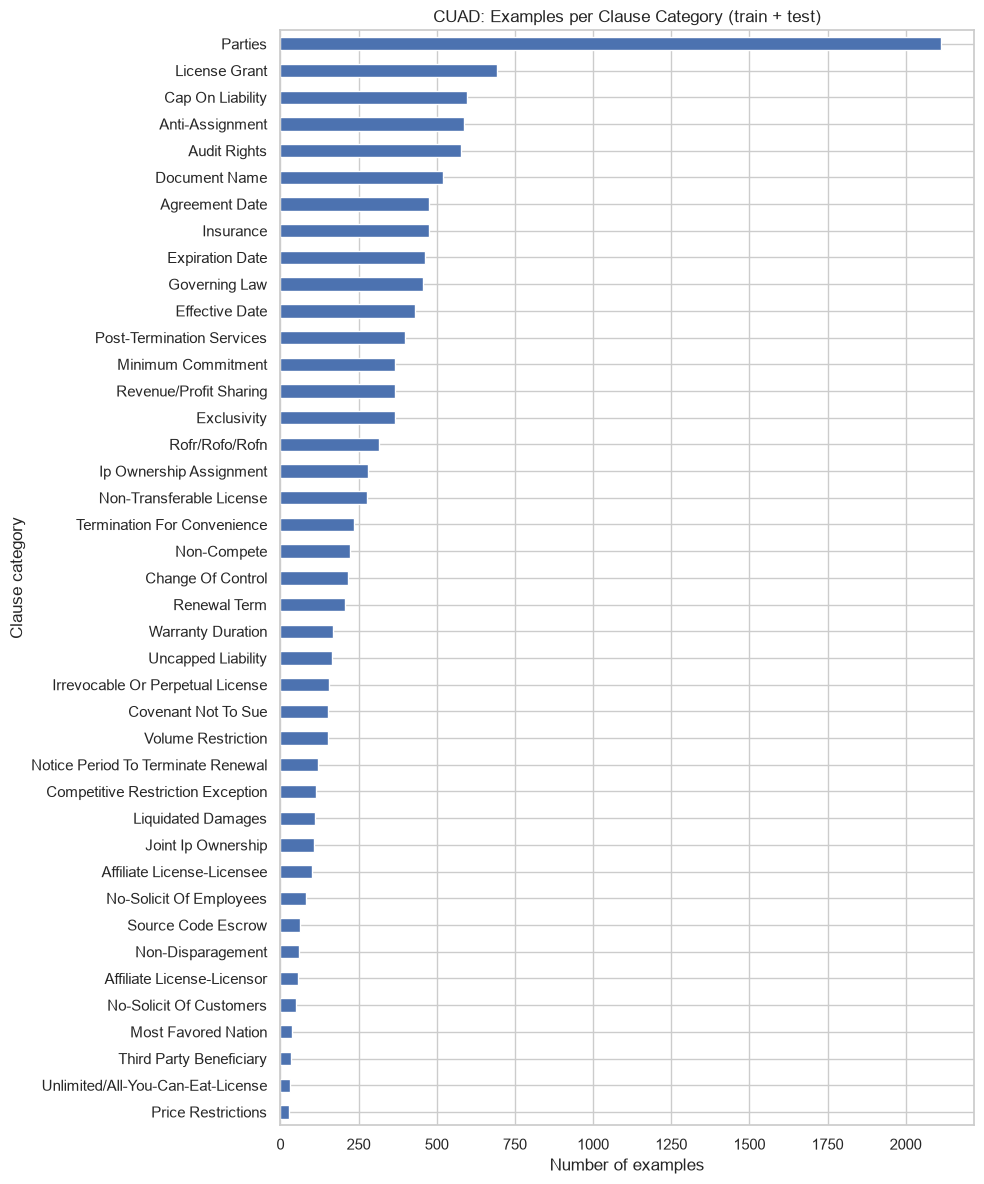

In [5]:
fig, ax = plt.subplots(figsize=(10, 12))
category_counts.sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Number of examples")
ax.set_ylabel("Clause category")
ax.set_title("CUAD: Examples per Clause Category (train + test)")
plt.tight_layout()
plt.show()

## 2. Missing values, empty answers, and malformed examples

In [6]:
print("Null counts:")
df.isnull().sum()

Null counts:


id          0
title       0
context     0
question    0
answers     0
source      0
lan         0
split       0
dtype: int64

In [7]:
for col in ["context", "question", "title"]:
    n_blank = (df[col].str.strip() == "").sum()
    print(f"Blank '{col}': {n_blank}")

Blank 'context': 0
Blank 'question': 0
Blank 'title': 0


In [8]:
# CUAD is set up so every contract gets one row per clause category, even
# when that clause type isn't present in the contract - those rows have an
# empty answers["text"] list by design, not by error. Worth quantifying
# since it affects how we frame this as an extraction task later.
df["has_answer"] = df["answers"].apply(lambda a: len(a["text"]) > 0)
print(df["has_answer"].value_counts())
print(f"\n{(~df['has_answer']).mean() * 100:.1f}% of rows have no answer span for that category")

has_answer
True    12422
Name: count, dtype: int64

0.0% of rows have no answer span for that category


In [9]:
# Sanity check: where an answer exists, does answer_start actually point to
# the matching substring in context? Misalignment would break span-based
# training labels.
def answer_aligned(row):
    answers = row["answers"]
    if len(answers["text"]) == 0:
        return True
    for text, start in zip(answers["text"], answers["answer_start"]):
        if row["context"][start:start + len(text)] != text:
            return False
    return True


df["answer_aligned"] = df.apply(answer_aligned, axis=1)
n_misaligned = (~df["answer_aligned"]).sum()
print(f"Rows where answer_start doesn't match the answer text: {n_misaligned}")
if n_misaligned:
    display(df.loc[~df["answer_aligned"], ["id", "question", "answers"]].head(10))

Rows where answer_start doesn't match the answer text: 0


In [10]:
n_dupe_ids = df.duplicated(subset="id").sum()
print(f"Duplicate ids: {n_dupe_ids}")

Duplicate ids: 0


## 3. Context (contract) length distribution in tokens

Each contract's `context` repeats once per clause question (~41x), so we tokenize each unique contract only once rather than re-tokenizing duplicates. Using the LegalBERT tokenizer directly so the token counts reflect its actual input limit.

In [11]:
from transformers import logging as hf_logging

hf_logging.set_verbosity_error()  # silence the expected "sequence too long" warnings below

tokenizer = AutoTokenizer.from_pretrained("nlpaueb/legal-bert-base-uncased")

In [12]:
unique_contracts = df.drop_duplicates(subset="title")[["title", "context"]]
print(f"Unique contracts: {len(unique_contracts)}")

token_counts = unique_contracts["context"].apply(
    lambda text: len(tokenizer.encode(text, add_special_tokens=True))
)

Unique contracts: 510


In [13]:
max_len = tokenizer.model_max_length
print(token_counts.describe())
print(f"\nLegalBERT max sequence length: {max_len}")
print(f"% of contracts exceeding max length: {(token_counts > max_len).mean() * 100:.1f}%")

count      510.000000
mean     10651.266667
std      11721.608393
min        168.000000
25%       3269.250000
50%       6643.500000
75%      13475.750000
max      78960.000000
Name: context, dtype: float64

LegalBERT max sequence length: 512
% of contracts exceeding max length: 96.7%


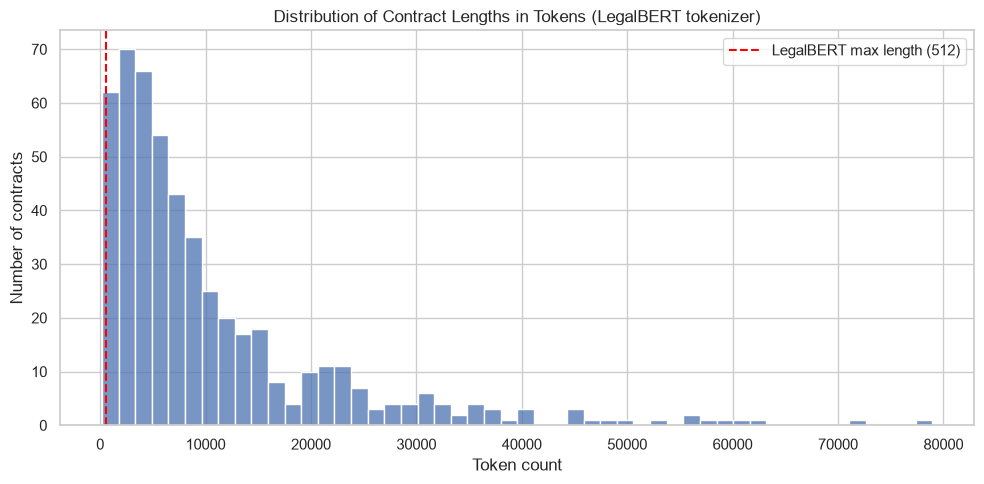

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(token_counts, bins=50, ax=ax)
ax.axvline(max_len, color="red", linestyle="--", label=f"LegalBERT max length ({max_len})")
ax.set_xlabel("Token count")
ax.set_ylabel("Number of contracts")
ax.set_title("Distribution of Contract Lengths in Tokens (LegalBERT tokenizer)")
ax.legend()
plt.tight_layout()
plt.show()

---

## Cleaning Pipeline

The cells below load `cuad_clean.csv` — the full positive + negative dataset
built directly from the official Atticus Project JSON files — and produce
`cuad_final.csv` as the single source of truth for all downstream notebooks.

In [15]:
PROCESSED_DIR = Path("../data/processed")

df = pd.read_csv(PROCESSED_DIR / "cuad_clean.csv")
rows_start = len(df)
print(f"Loaded cuad_clean.csv: {df.shape}")
df.dtypes

Loaded cuad_clean.csv: (26632, 7)


contract_id        str
category           str
context            str
answer_text        str
answer_start     int64
is_answerable     bool
split              str
dtype: object

In [16]:
df.head(3)

,contract_id,category,context,answer_text,answer_start,is_answerable,split
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,EXHIBIT 10.6\n\n ...,DISTRIBUTOR AGREEMENT,44,True,train
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,EXHIBIT 10.6\n\n ...,Distributor,244,True,train
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,EXHIBIT 10.6\n\n ...,Electric City of Illinois L.L.C.,49574,True,train


## Step 1: Category column

The `category` values were already extracted cleanly from the id field in
`build_cuad_dataset.py`, but we normalise here defensively: strip surrounding
whitespace, collapse any residual underscores, and squash double-spaces.

In [17]:
before_cats = set(df["category"])

df["category"] = (
    df["category"]
    .str.strip()
    .str.replace("_", " ", regex=False)
    .str.replace(r"\s{2,}", " ", regex=True)
)

after_cats = set(df["category"])
n_cat_changed = len(before_cats - after_cats)
print(f"Category values changed by normalisation: {n_cat_changed}")
print(f"Unique categories: {df["category"].nunique()}")
print(sorted(df["category"].unique()))

Category values changed by normalisation: 0
Unique categories: 41
['Affiliate License-Licensee', 'Affiliate License-Licensor', 'Agreement Date', 'Anti-Assignment', 'Audit Rights', 'Cap On Liability', 'Change Of Control', 'Competitive Restriction Exception', 'Covenant Not To Sue', 'Document Name', 'Effective Date', 'Exclusivity', 'Expiration Date', 'Governing Law', 'Insurance', 'Ip Ownership Assignment', 'Irrevocable Or Perpetual License', 'Joint Ip Ownership', 'License Grant', 'Liquidated Damages', 'Minimum Commitment', 'Most Favored Nation', 'No-Solicit Of Customers', 'No-Solicit Of Employees', 'Non-Compete', 'Non-Disparagement', 'Non-Transferable License', 'Notice Period To Terminate Renewal', 'Parties', 'Post-Termination Services', 'Price Restrictions', 'Renewal Term', 'Revenue/Profit Sharing', 'Rofr/Rofo/Rofn', 'Source Code Escrow', 'Termination For Convenience', 'Third Party Beneficiary', 'Uncapped Liability', 'Unlimited/All-You-Can-Eat-License', 'Volume Restriction', 'Warranty Du

## Step 2: Answer text — strip whitespace, flag short spans

Strip leading/trailing whitespace from every answer span, then flag answerable
rows whose span is under 5 characters as potential noise. We flag rather than
drop so you can inspect them before deciding.

In [18]:
SHORT_THRESHOLD = 5

answer_before = df["answer_text"].fillna("").copy()
df["answer_text"] = df["answer_text"].fillna("").str.strip()
n_stripped = (df["answer_text"] != answer_before).sum()

df["short_answer_flag"] = (
    df["is_answerable"] & (df["answer_text"].str.len() < SHORT_THRESHOLD)
)
n_short = df["short_answer_flag"].sum()

print(f"Rows with answer_text whitespace stripped:         {n_stripped}")
print(f"Answerable rows flagged as short (<{SHORT_THRESHOLD} chars):  {n_short}")
if n_short:
    display(df[df["short_answer_flag"]][["contract_id", "category", "answer_text"]])

Rows with answer_text whitespace stripped:         0
Answerable rows flagged as short (<5 chars):  203


,contract_id,category,answer_text
372,"FTENETWORKS,INC_02_18_2016-EX-99.4-STRATEGIC A...",Parties,EDGE
373,"FTENETWORKS,INC_02_18_2016-EX-99.4-STRATEGIC A...",Parties,FTE
643,IntegrityFunds_20200121_485BPOS_EX-99.E UNDR C...,Parties,Fund
686,PREMIERBIOMEDICALINC_05_14_2020-EX-10.2-INTELL...,Parties,THI
689,PREMIERBIOMEDICALINC_05_14_2020-EX-10.2-INTELL...,Parties,Marv
...,...,...,...
25198,"PAXMEDICA,INC_07_02_2020-EX-10.12-Master Servi...",Parties,CRO
25731,ACCELERATEDTECHNOLOGIESHOLDINGCORP_04_24_2003-...,Parties,CCGI
25895,TEARDROPGOLFCO_10_23_1996-EX-10.12-ENDORSEMENT...,Parties,TPC
26018,PcquoteComInc_19990721_S-1A_EX-10.11_6377149_E...,Parties,PCQ


## Step 3: Context — unicode normalisation and whitespace

NFKC normalisation resolves ligatures, special whitespace characters, and
half-width variants that appear in scanned/OCR'd legal documents. We then
collapse horizontal whitespace runs and limit consecutive newlines to two.

In [19]:
import re
import unicodedata

def clean_context(text):
    text = unicodedata.normalize("NFKC", text)  # ligatures, special spaces
    text = re.sub(r"[ \t]{2,}", " ", text)      # collapse horizontal whitespace
    text = re.sub(r"\n{3,}", "\n\n", text)       # max two consecutive newlines
    return text.strip()

context_before = df["context"].copy()
df["context"] = df["context"].apply(clean_context)

n_ctx_changed = (df["context"] != context_before).sum()
print(f"Rows where context changed: {n_ctx_changed:,} / {len(df):,}")

Rows where context changed: 26,156 / 26,632


In [20]:
avg_before = context_before.str.len().mean()
avg_after  = df["context"].str.len().mean()
print(f"Mean context length before: {avg_before:,.0f} chars")
print(f"Mean context length after:  {avg_after:,.0f} chars")
print(f"Avg reduction:              {avg_before - avg_after:,.1f} chars ({(avg_before - avg_after) / avg_before * 100:.2f}%)")

Mean context length before: 61,884 chars
Mean context length after:  59,555 chars
Avg reduction:              2,329.1 chars (3.76%)


## Step 4: Add `context_length_tokens` column

Each contract's context is identical across its ~41 category rows, so we
tokenize each unique contract once and broadcast the count back. This is
the post-cleaning length — important for sizing the chunking strategy later.

In [21]:
from tqdm.auto import tqdm

unique_ctx = (
    df.drop_duplicates(subset="contract_id")[["contract_id", "context"]].copy()
)
print(f"Tokenizing {len(unique_ctx)} unique contracts...")

token_len_map = {
    row["contract_id"]: len(tokenizer.encode(row["context"], add_special_tokens=True))
    for _, row in tqdm(unique_ctx.iterrows(), total=len(unique_ctx), desc="tokenising")
}

df["context_length_tokens"] = df["contract_id"].map(token_len_map)
print(f"\nToken length stats across {len(unique_ctx)} contracts:")
print(df.drop_duplicates(subset="contract_id")["context_length_tokens"].describe())

Tokenizing 510 unique contracts...


tokenising:   0%|          | 0/510 [00:00<?, ?it/s]

tokenising:   2%|▏         | 11/510 [00:00<00:05, 99.77it/s]

tokenising:   4%|▍         | 21/510 [00:00<00:05, 88.48it/s]

tokenising:   6%|▌         | 30/510 [00:00<00:06, 69.20it/s]

...

tokenising:  95%|█████████▍| 482/510 [00:06<00:00, 89.89it/s]

tokenising:  96%|█████████▋| 492/510 [00:06<00:00, 78.94it/s]

tokenising:  98%|█████████▊| 501/510 [00:06<00:00, 74.91it/s]

tokenising: 100%|██████████| 510/510 [00:06<00:00, 73.82it/s]


Token length stats across 510 contracts:
count      510.000000
mean     10663.117647
std      11745.233572
min        168.000000
25%       3269.250000
50%       6643.500000
75%      13475.750000
max      78960.000000
Name: context_length_tokens, dtype: float64


## Step 5: Save `cuad_final.csv` and before/after summary

In [22]:
OUTPUT_PATH = PROCESSED_DIR / "cuad_final.csv"
df.to_csv(OUTPUT_PATH, index=False)

print("=" * 60)
print("BEFORE / AFTER CLEANING SUMMARY")
print("=" * 60)
print(f"Rows loaded  (cuad_clean.csv):    {rows_start:>8,}")
print(f"Rows saved   (cuad_final.csv):    {len(df):>8,}  (no rows dropped)")
print(f"Columns in final CSV:             {df.shape[1]:>8}")
print()
print("Step 1 — Category normalisation:")
print(f"  Labels changed:                 {n_cat_changed:>8}")
print(f"  Unique categories:              {df["category"].nunique():>8}")
print()
print("Step 2 — Answer text:")
print(f"  Rows stripped of whitespace:    {n_stripped:>8}")
print(f"  Rows flagged short (<5 chars):  {n_short:>8}  (kept, flag col added)")
print()
print("Step 3 — Context cleaning:")
print(f"  Rows changed:                   {n_ctx_changed:>8,}")
print(f"  Avg char reduction per row:     {avg_before - avg_after:>8.1f} chars")
print()
print("Step 4 — Token lengths:")
print(f"  Contracts tokenised:            {len(unique_ctx):>8}")
print(f"  Median tokens:                  {df["context_length_tokens"].median():>8,.0f}")
print(f"  Max tokens:                     {df["context_length_tokens"].max():>8,}")
print(f"  Rows exceeding 512-token limit: {(df["context_length_tokens"] > 512).sum():>8,} ({(df["context_length_tokens"] > 512).mean()*100:.1f}%)")
print()
print(f"Saved → {OUTPUT_PATH}")

BEFORE / AFTER CLEANING SUMMARY
Rows loaded  (cuad_clean.csv):      26,632
Rows saved   (cuad_final.csv):      26,632  (no rows dropped)
Columns in final CSV:                    9

Step 1 — Category normalisation:
  Labels changed:                        0
  Unique categories:                    41

Step 2 — Answer text:
  Rows stripped of whitespace:           0
  Rows flagged short (<5 chars):       203  (kept, flag col added)

Step 3 — Context cleaning:
  Rows changed:                     26,156
  Avg char reduction per row:       2329.1 chars

Step 4 — Token lengths:
  Contracts tokenised:                 510
  Median tokens:                     7,853
  Max tokens:                       78,960
  Rows exceeding 512-token limit:   25,903 (97.3%)

Saved → ../data/processed/cuad_final.csv


## Short-answer resolution

Of the 203 short-span rows flagged above, 192 are legitimate short party
abbreviations (IBM, Fox, AT&T, EDGE, etc.) and are kept as-is.

The remaining **11 rows** are clear noise — redaction placeholders
(`[●]`, `[*]`, `[•]`, `[ ]`) or wrong extractions (`.`, `This`).
These are dropped and `cuad_final.csv` is re-saved.

In [ ]:
NOISE = {".", "[●]", "[*]", "[•]", "[ ]", "This"}

before = len(df)
df = df[~df["answer_text"].isin(NOISE)].reset_index(drop=True)
dropped = before - len(df)

print(f"Noise rows dropped:     {dropped}")
print(f"Final rows in dataset:  {len(df):,}")
print(f"Answerable rows:        {df['is_answerable'].sum():,}")
print(f"Unanswerable rows:      {(~df['is_answerable']).sum():,}")

df.to_csv(PROCESSED_DIR / "cuad_final.csv", index=False)
print(f"\nSaved → {PROCESSED_DIR / 'cuad_final.csv'}")